<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/5_2_Systems_Biology_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Session 2 — Systems Biology and Network Analysis

### Aim
Construct and analyze a gene–gene interaction network from an expression-like matrix, calculate centrality measures, detect communities, and identify candidate hub genes.

### Concepts
Network nodes = genes/proteins  
Edges = functional/interaction relationships  
Degree, betweenness, closeness = centrality measures  
Communities = densely connected groups

In [1]:
!pip -q install networkx pandas numpy scikit-learn matplotlib seaborn

import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler

np.random.seed(7)
print("Environment ready")

Environment ready


## 1. Create a synthetic expression dataset

A latent module structure is embedded into the data to mimic co-regulated genes.

In [2]:
n_samples = 80
n_genes = 40
samples = [f"S{i:03d}" for i in range(n_samples)]

expr = np.random.normal(size=(n_samples, n_genes))
genes = [f"Gene_{i:02d}" for i in range(n_genes)]

# Create 4 co-expression modules
for start in [0,10,20,30]:
    signal = np.random.normal(size=n_samples)
    expr[:, start:start+10] += signal[:,None] * 0.8

expr = pd.DataFrame(expr, index=samples, columns=genes)
expr_z = pd.DataFrame(StandardScaler().fit_transform(expr), index=samples, columns=genes)
display(expr_z.iloc[:5,:8])

,Gene_00,Gene_01,Gene_02,Gene_03,Gene_04,Gene_05,Gene_06,Gene_07
S000,0.700549,-0.788604,-0.381217,-0.225342,-1.251935,-0.625023,-0.609412,-2.153837
S001,0.307568,-0.334958,0.303080,-0.917725,-1.690484,-1.725203,-0.049751,1.538722
S002,0.668205,0.856404,0.668023,-0.516739,0.002036,-0.317428,-0.087776,1.269201
S003,-0.502294,-0.639624,0.530373,0.049742,-0.220737,0.422669,0.201017,0.138331
S004,-1.302885,-0.076487,1.117819,-1.757405,-0.141016,0.330952,-1.023640,-0.056499


## 2. Build a correlation network

Only strong correlations are converted into edges. The threshold should be chosen carefully in real studies and preferably supported by multiple-testing control and independent evidence.

In [3]:
corr = expr_z.corr(method="pearson")

threshold = 0.60
G = nx.Graph()
G.add_nodes_from(genes)

for i in range(n_genes):
    for j in range(i+1, n_genes):
        r = corr.iloc[i,j]
        if abs(r) >= threshold:
            G.add_edge(genes[i], genes[j], weight=float(r), abs_weight=float(abs(r)))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G),3))

Nodes: 40
Edges: 0
Density: 0


## 3. Visualize the network

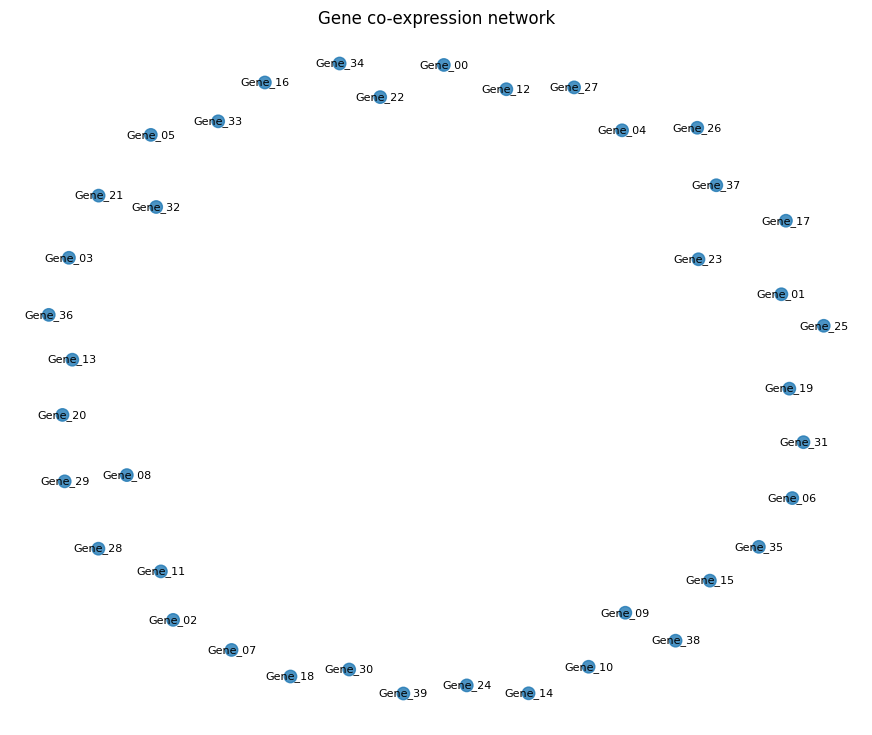

In [4]:
plt.figure(figsize=(11,9))
pos = nx.spring_layout(G, seed=42)
node_sizes = [80 + 60*G.degree(n) for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=.8)
nx.draw_networkx_edges(G, pos, alpha=.25)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Gene co-expression network")
plt.axis("off")
plt.show()

## 4. Calculate centrality measures

In [5]:
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)

centrality = pd.DataFrame({
    "DegreeCentrality": pd.Series(degree),
    "Betweenness": pd.Series(betweenness),
    "Closeness": pd.Series(closeness),
    "Degree": dict(G.degree())
}).sort_values("DegreeCentrality", ascending=False)

display(centrality.head(15))

,DegreeCentrality,Betweenness,Closeness,Degree
Gene_00,0.0,0.0,0.0,0
Gene_01,0.0,0.0,0.0,0
Gene_02,0.0,0.0,0.0,0
Gene_03,0.0,0.0,0.0,0
Gene_04,0.0,0.0,0.0,0
Gene_05,0.0,0.0,0.0,0
Gene_06,0.0,0.0,0.0,0
Gene_07,0.0,0.0,0.0,0
Gene_08,0.0,0.0,0.0,0
Gene_09,0.0,0.0,0.0,0


## 5. Community detection

Communities can reveal functional modules. Greedy modularity is used here because it is easy to reproduce without external services.

In [6]:
communities = list(nx.community.greedy_modularity_communities(G))
print("Number of communities:", len(communities))
for i, comm in enumerate(communities, 1):
    print(f"Community {i}: {len(comm)} nodes ->", sorted(comm)[:10])

Number of communities: 40
Community 1: 1 nodes -> ['Gene_00']
Community 2: 1 nodes -> ['Gene_01']
Community 3: 1 nodes -> ['Gene_02']
Community 4: 1 nodes -> ['Gene_03']
Community 5: 1 nodes -> ['Gene_04']
Community 6: 1 nodes -> ['Gene_05']
Community 7: 1 nodes -> ['Gene_06']
Community 8: 1 nodes -> ['Gene_07']
Community 9: 1 nodes -> ['Gene_08']
Community 10: 1 nodes -> ['Gene_09']
Community 11: 1 nodes -> ['Gene_10']
Community 12: 1 nodes -> ['Gene_11']
Community 13: 1 nodes -> ['Gene_12']
Community 14: 1 nodes -> ['Gene_13']
Community 15: 1 nodes -> ['Gene_14']
Community 16: 1 nodes -> ['Gene_15']
Community 17: 1 nodes -> ['Gene_16']
Community 18: 1 nodes -> ['Gene_17']
Community 19: 1 nodes -> ['Gene_18']
Community 20: 1 nodes -> ['Gene_19']
Community 21: 1 nodes -> ['Gene_20']
Community 22: 1 nodes -> ['Gene_21']
Community 23: 1 nodes -> ['Gene_22']
Community 24: 1 nodes -> ['Gene_23']
Community 25: 1 nodes -> ['Gene_24']
Community 26: 1 nodes -> ['Gene_25']
Community 27: 1 nodes

## 6. Hub genes and module interpretation

In [7]:
top_hubs = centrality.head(10).copy()
top_hubs["CandidateRole"] = "Network hub / candidate regulator"
display(top_hubs)

# Module-level average expression
module_summary = []
for i, comm in enumerate(communities, 1):
    genes_i = sorted(comm)
    module_summary.append({
        "Module": i,
        "Size": len(genes_i),
        "MeanExpression": expr_z[genes_i].mean().mean()
    })
display(pd.DataFrame(module_summary))

,DegreeCentrality,Betweenness,Closeness,Degree,CandidateRole
Gene_00,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_01,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_02,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_03,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_04,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_05,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_06,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_07,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_08,0.0,0.0,0.0,0,Network hub / candidate regulator
Gene_09,0.0,0.0,0.0,0,Network hub / candidate regulator


,Module,Size,MeanExpression
0,1,1,-2.775558e-17
1,2,1,-4.440892e-17
2,3,1,-1.096345e-16
3,4,1,-5.551115e-17
4,5,1,-1.110223e-17
5,6,1,5.551115e-17
6,7,1,1.110223e-17
7,8,1,-4.996004e-17
8,9,1,1.110223e-17
9,10,1,1.110223e-17


## 7. Export network results

In [8]:
centrality.to_csv("network_centrality_results.csv")
edges = nx.to_pandas_edgelist(G)
edges.to_csv("gene_network_edges.csv", index=False)
print("Saved network_centrality_results.csv and gene_network_edges.csv")

Saved network_centrality_results.csv and gene_network_edges.csv


## Student exercises

1. Repeat the network at correlation thresholds 0.50, 0.70 and 0.80.
2. Compare degree and betweenness rankings.
3. Remove the top hub and recalculate network density.
4. Investigate how sample size affects correlation-network stability.
5. Propose how you would replace this synthetic network with STRING or BioGRID interactions.
6. Extend the workflow to a gene–drug or gene–disease bipartite network.

### Research extension
Combine differential expression with network centrality and prioritize genes that are both significantly altered and topological hubs.